## Import libraries for the PCA (Dimensionality Reduction)

In [1]:
# Import necessary libraries
import pandas as pd  # to load the dataframe
from sklearn.preprocessing import StandardScaler  # to standardize the features
from sklearn.decomposition import PCA  # to apply PCA
import seaborn as sns  # to plot the heat maps

## Load the dataset (from the matlab data)

In [2]:
import scipy.io
data = scipy.io.loadmat('data/Rat8-20130713_proces_bin1.mat') # session 13 from rat 8 version not trunked
print("variables disponibles: ", data.keys())

variables disponibles:  dict_keys(['__header__', '__version__', '__globals__', 'cellexc', 'event', 'metadata', 'posit', 'ripl', 'spik'])


In [3]:
metadata = pd.DataFrame(data['metadata'])
metadata.head()

,0,1,2,3
0,1,3,1,1
1,2,6,1,1
2,3,7,1,1
3,4,8,1,1
4,5,9,1,1


## Variables

Neuronal activity (in Hz)

- spik.prerun : binned spikes from the prerun session (matrix of size neurons x time bins)
- spik.run : binned spikes from the run session (matrix of size neurons x time bins)
- spik.postrun: binned spikes from the postrun session (matrix of size neurons x time bins)

Normalized position in the box

- posit.prerun: x and y position during the prerun session (matrix of size 2 x time bins)
- posit.run : : x and y position during the run session (matrix of size 2 x time bins)
- posit.postrun : : x and y position during the postrun session (matrix of size 2 x time bins)

In [ ]:
spik = data['spik']

spik_prerun  = spik['prerun'][0, 0]
spik_run     = spik['run'][0, 0]
spik_postrun = spik['postrun'][0, 0]

print("SPIK :\n", spik)

posit = data['posit']

posit_prerun  = posit['prerun'][0, 0]
posit_run     = posit['run'][0, 0]
posit_postrun = posit['postrun'][0, 0]

print("POSIT :\n", posit)


SPIK :
 [[(array([[ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0, 10, ...,  0, 10,  0],
         ...,
         [ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ...,  0,  0,  0]], shape=(252, 2063), dtype=uint8), array([[ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ..., 10,  0,  0],
         ...,
         [ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ...,  0,  0,  0]], shape=(252, 32205), dtype=uint8), array([[ 0,  0,  0, ...,  0,  0,  0],
         [10,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ...,  0,  0,  0],
         ...,
         [ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ...,  0,  0,  0],
         [ 0,  0,  0, ...,  0,  0,  0]], shape=(252, 2650), dtype=uint8))                                       ]]
POSIT :
 [[(array([[       nan,        nan,        nan, ..., 0.90984975, 0.90813022,
    

[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ... 10  0  0]
 ...
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]
size of neurons x time bins : (252, 32205)


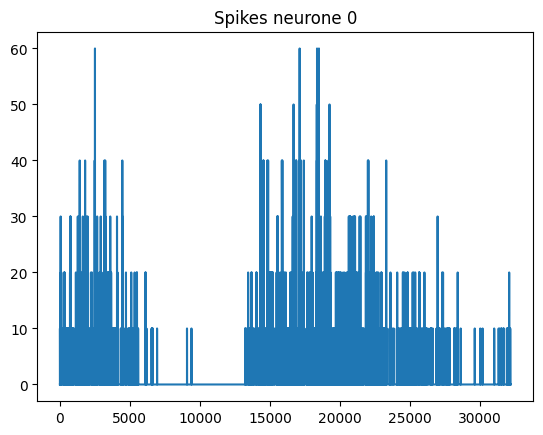

In [5]:
import matplotlib.pyplot as plt

print(spik_run)
# print(len(spik_run))
print("size of neurons x time bins :", spik_run.shape)

plt.plot(spik_run[0])
plt.title("Spikes neurone 0")
plt.show()



## Standardize the features (test)


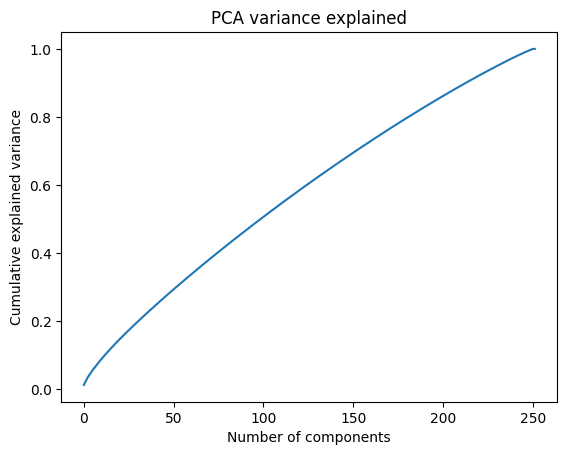

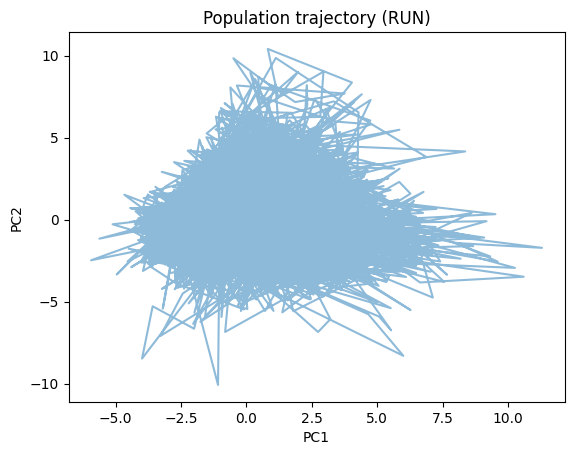

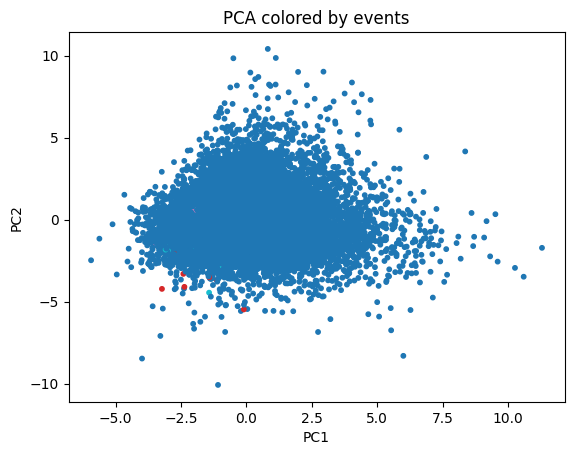

In [6]:
import numpy as np
event = data['event']

X = spik_run.T   # (temps × neurones)

bin_size = 2   # 2 bins = 200 ms

n_time, n_neurons = X.shape
n_bins = n_time // bin_size

X_binned = X[:n_bins*bin_size].reshape(
    n_bins, bin_size, n_neurons
).sum(axis=1)

X_binned.shape  # (time_bins, 256)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_binned)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA variance explained")
plt.show()

plt.plot(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Population trajectory (RUN)")
plt.show()


event_run = event['run'][0,0].flatten()
event_bin = event_run[:n_bins*bin_size].reshape(n_bins, bin_size).max(axis=1)

colors = np.zeros(len(event_bin))
colors[event_bin == 2] = 1   # right
colors[event_bin == 3] = 2   # left
colors[event_bin == 1] = 3   # airpuff

plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, cmap='tab10', s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA colored by events")
plt.show()


## Plot the number of lap for the rat 8

event.prerun, event.run and event.postrun (matrix of size 1 x time bins) :

If an airpuff was delivered during the time bin, there will be a 1.
2 stands for right reward and 3 for left reward.

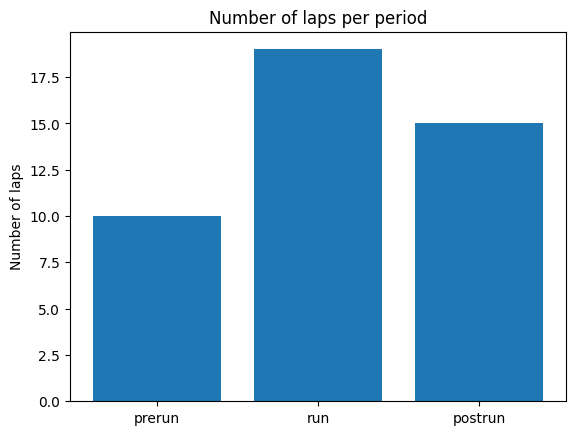

In [7]:
import numpy as np

event = data['event']

event_prerun  = event['prerun'][0, 0].flatten()
event_run     = event['run'][0, 0].flatten()
event_postrun = event['postrun'][0, 0].flatten()

def count_laps(event_vector):
    right = np.sum(event_vector == 2)
    left  = np.sum(event_vector == 3)
    total = right + left
    return total

laps = {
    "prerun":  count_laps(event_prerun),
    "run":     count_laps(event_run),
    "postrun": count_laps(event_postrun)
}

laps

labels = ["prerun", "run", "postrun"]
total  = [laps[l] for l in labels]

x = np.arange(len(labels))

plt.bar(x, total)
plt.xticks(x, labels)
plt.ylabel("Number of laps")
plt.title("Number of laps per period")
plt.show()


## Plot the time for each lap for rat 8

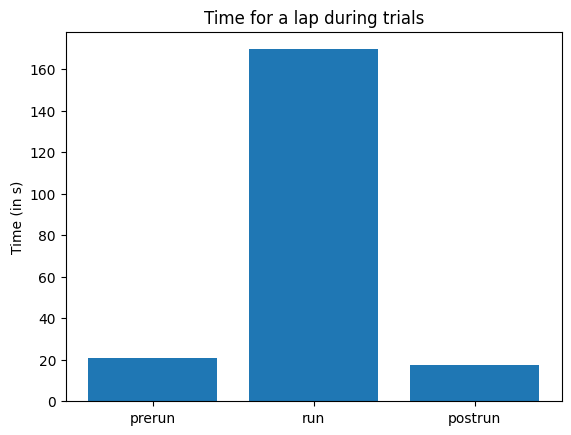

In [8]:
# time per lap = number of laps / final time
# un peu simplifié mais bon ...
# 1 time bin = 100ms (time in ms)

time_prerun =  len(event_prerun) / (laps["prerun"] * 10)
time_run = len(event_run) / (laps["run"] * 10)
time_postrun = len(event_postrun) / (laps["postrun"] * 10)

times = [time_prerun, time_run, time_postrun]

plt.bar(labels, times)

plt.ylabel("Time (in s)")
plt.title("Time for a lap during trials")
plt.show()


## Comparison between the rat 8 and the rat 11


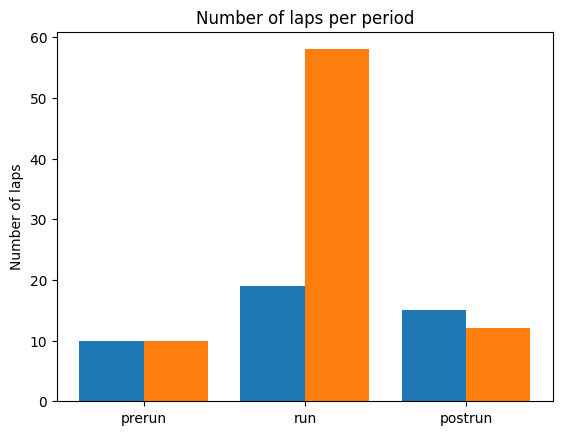

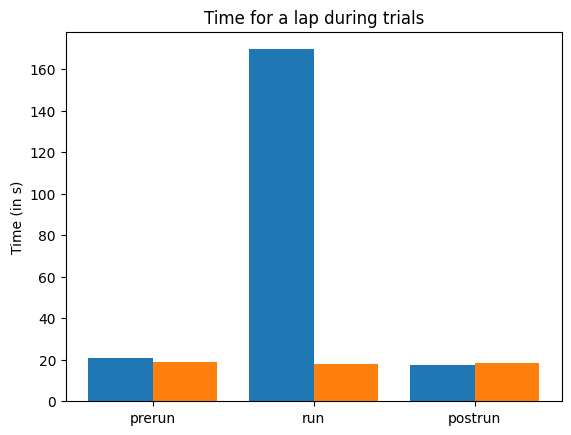

In [9]:
data_2 = scipy.io.loadmat('data/Rat11-20150327_proces_bin1.mat') # session 27 from rat 11 version not trunked

event_2 = data_2['event']

event_prerun_2  = event_2['prerun'][0, 0].flatten()
event_run_2   = event_2['run'][0, 0].flatten()
event_postrun_2 = event_2['postrun'][0, 0].flatten()

laps_2 = {
    "prerun":  count_laps(event_prerun_2),
    "run":     count_laps(event_run_2),
    "postrun": count_laps(event_postrun_2)
}

laps_2

total_2  = [laps_2[l] for l in labels]

w, x = 0.4, np.arange(len(labels))

fig, ax = plt.subplots()
ax.bar(x-w/2, total, width=w, label="Rat 8")
ax.bar(x+w/2, total_2, width=w, label="Rat 11")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Number of laps")
ax.set_title("Number of laps per period")
plt.show() # first graph with both rat (nb of laps)

time_prerun_2 =  len(event_prerun_2) / (laps_2["prerun"] * 10)
time_run_2 = len(event_run_2) / (laps_2["run"] * 10)
time_postrun_2 = len(event_postrun_2) / (laps_2["postrun"] * 10)

times_2 = [time_prerun_2, time_run_2, time_postrun_2]

fig, ax = plt.subplots()
ax.bar(x-w/2, times, width=w, label="Rat 8")
ax.bar(x+w/2, times_2, width=w, label="Rat 11")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Time (in s)")
ax.set_title("Time for a lap during trials")
plt.show()

In [ ]:
y = 0
i = 0

for x in event_run:
    i += 1
    if (x==2 or x==3) :## Comparison between the rat 8 and the rat 11
        y +=1
        if y == 19 :
            print(i)
            break

print("nb de bins finaux ne contenant que des 0: ", len(event_run)-i)

27329
nb de bins finaux ne contenant que des 0:  4876
